# Proyecto 1 - Monitoreo transaccional: detectar lo que el orden revela

Deep Learning 2026 - Universidad del Valle de Guatemala

Equipo:

- Nina Najera - 231088
- José Antón - 221041

Este notebook implementa la línea base sin orden, el modelo secuencial, la apuesta del equipo, las dos pruebas de falsificación y el análisis económico. La ruta elegida usa datos sintéticos con un generador propio y una semilla fija.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import os
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

SEED = 20260905
np.random.seed(SEED)
torch.manual_seed(SEED)

for folder in ["data", "figs", "artefactos"]:
    os.makedirs(folder, exist_ok=True)

## 1. Generador de datos sintéticos

Se simulan 700 tarjetahabientes durante 120 días. Cada cliente tiene un perfil de monto, comercios, canal y horario habitual.

Se incluyen tres mecanismos de fraude:

1. `escalada`: varias compras pequeñas seguidas por una compra grande. El orden de los eventos puede aportar información.
2. `rafaga`: varias transacciones pequeñas en comercios distintos y en pocos minutos.
3. `canal_raro`: una transacción grande en un horario y una categoría poco habituales.

Se espera que el modelo secuencial tenga dificultades en `canal_raro` porque una ventana corta no siempre representa el comportamiento habitual del cliente. El generador usa una semilla fija y se comprueba que dos ejecuciones producen exactamente los mismos datos.

In [2]:
"""
Generador de transacciones sintéticas — Banco del Altiplano.
Produce los MISMOS datos dado el mismo seed (requisito del enunciado).

Tres tipos de fraude:
  1) "escalada"   -> depende PRINCIPALMENTE del orden (varias compras pequeñas
                      seguidas de una grande, en ese orden).
  2) "rafaga"     -> tarjeta clonada / card testing: muchas transacciones
                      pequeñas en distintos comercios en pocos minutos.
                      Se detecta bien con agregados (conteo/hora, diversidad).
  3) "canal_raro" -> cambio súbito de canal/categoría/hora tras un patrón
                      estable. Señal fuerte en la transacción misma (monto,
                      hora, categoría), poco dependiente del orden interno.
"""
import numpy as np
import pandas as pd

SEED = 20260905
MERCHANT_CATEGORIES = [
    "supermercado", "restaurante", "combustible", "farmacia", "ropa",
    "electronica", "servicios", "entretenimiento", "viajes", "otros",
]
CHANNELS = ["pos_presencial", "online", "cajero"]

N_CLIENTS = 700
START_DATE = pd.Timestamp("2026-01-01")
HORIZON_DAYS = 120  # ~4 meses


def _client_profile(rng):
    return {
        "base_amt_mean": rng.uniform(60, 260),
        "base_amt_sigma": rng.uniform(0.35, 0.75),
        "tx_per_day_lambda": rng.uniform(0.4, 2.2),
        "fav_categories": rng.choice(MERCHANT_CATEGORIES, size=rng.integers(2, 5), replace=False),
        "fav_channel": rng.choice(CHANNELS, p=[0.65, 0.25, 0.10]),
        "active_hours": rng.choice([  # franja horaria habitual del cliente
            (7, 22), (8, 20), (6, 23), (9, 21)
        ]),
    }


def _gen_normal_stream(client_id, profile, rng):
    """Genera transacciones legítimas de un cliente durante el horizonte."""
    rows = []
    t = START_DATE + pd.Timedelta(hours=rng.uniform(0, 24))
    end = START_DATE + pd.Timedelta(days=HORIZON_DAYS)
    while t < end:
        gap_days = rng.exponential(1.0 / profile["tx_per_day_lambda"])
        t = t + pd.Timedelta(days=gap_days)
        if t >= end:
            break
        lo, hi = profile["active_hours"]
        hour = int(np.clip(rng.normal((lo + hi) / 2, (hi - lo) / 4), 0, 23))
        t = t.normalize() + pd.Timedelta(hours=hour, minutes=int(rng.uniform(0, 59)))
        amt = float(np.clip(rng.lognormal(np.log(profile["base_amt_mean"]), profile["base_amt_sigma"]), 8, 3000))
        cat = rng.choice(profile["fav_categories"]) if rng.random() < 0.85 else rng.choice(MERCHANT_CATEGORIES)
        chan = profile["fav_channel"] if rng.random() < 0.9 else rng.choice(CHANNELS)
        rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                          merchant_category=cat, channel=chan, fraud=0, fraud_type="none"))
    return rows


def _inject_escalada(client_id, profile, rng, end_ts):
    """Tipo 1: 3-5 compras pequeñas seguidas de 1 grande, en minutos. ORDEN IMPORTA."""
    t0 = START_DATE + pd.Timedelta(days=rng.uniform(5, HORIZON_DAYS - 2))
    n_small = int(rng.integers(3, 6))
    rows = []
    t = t0
    for _ in range(n_small):
        t = t + pd.Timedelta(minutes=rng.uniform(2, 12))
        amt = float(rng.uniform(20, 150))
        rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                          merchant_category=rng.choice(MERCHANT_CATEGORIES), channel="online",
                          fraud=0, fraud_type="escalada_previo"))
    t = t + pd.Timedelta(minutes=rng.uniform(2, 10))
    amt_large = float(rng.uniform(1500, 6000))
    rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt_large, 2),
                      merchant_category=rng.choice(MERCHANT_CATEGORIES), channel="online",
                      fraud=1, fraud_type="escalada"))
    return rows


def _inject_rafaga(client_id, profile, rng, end_ts):
    """Tipo 2: card testing — muchas tx pequeñas en distintos comercios, pocos minutos."""
    t0 = START_DATE + pd.Timedelta(days=rng.uniform(5, HORIZON_DAYS - 2))
    n = int(rng.integers(6, 11))
    rows = []
    t = t0
    cats = rng.choice(MERCHANT_CATEGORIES, size=n, replace=True)
    for i in range(n):
        t = t + pd.Timedelta(minutes=rng.uniform(0.5, 3))
        amt = float(rng.uniform(5, 50))
        rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                          merchant_category=cats[i], channel="online",
                          fraud=1, fraud_type="rafaga"))
    return rows


def _inject_canal_raro(client_id, profile, rng, end_ts):
    """Tipo 3: transacción única, fuera de patrón (hora/canal/categoría/monto)."""
    t0 = START_DATE + pd.Timedelta(days=rng.uniform(5, HORIZON_DAYS - 1))
    hour = int(rng.choice([1, 2, 3, 4]))
    t = t0.normalize() + pd.Timedelta(hours=hour, minutes=int(rng.uniform(0, 59)))
    amt = float(rng.uniform(1200, 5000))
    off_categories = [c for c in MERCHANT_CATEGORIES if c not in profile["fav_categories"]]
    cat = rng.choice(off_categories) if len(off_categories) else rng.choice(MERCHANT_CATEGORIES)
    return [dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                 merchant_category=cat, channel="online",
                 fraud=1, fraud_type="canal_raro")]


def generate(seed=SEED, n_clients=N_CLIENTS, verbose=True):
    rng = np.random.default_rng(seed)
    all_rows = []
    end_ts = START_DATE + pd.Timedelta(days=HORIZON_DAYS)
    fraud_clients = rng.choice(n_clients, size=int(n_clients * 0.26), replace=False)
    fraud_type_for_client = {}
    types_cycle = ["escalada", "rafaga", "canal_raro"]
    for i, cid in enumerate(fraud_clients):
        fraud_type_for_client[int(cid)] = types_cycle[i % 3]

    for cid in range(n_clients):
        crng = np.random.default_rng(seed + cid + 1)
        profile = _client_profile(crng)
        rows = _gen_normal_stream(cid, profile, crng)
        if cid in fraud_type_for_client:
            ftype = fraud_type_for_client[cid]
            n_events = int(crng.integers(1, 4))  # 1-3 episodios de fraude por cliente afectado
            for _ in range(n_events):
                if ftype == "escalada":
                    rows += _inject_escalada(cid, profile, crng, end_ts)
                elif ftype == "rafaga":
                    rows += _inject_rafaga(cid, profile, crng, end_ts)
                else:
                    rows += _inject_canal_raro(cid, profile, crng, end_ts)
        all_rows.extend(rows)

    df = pd.DataFrame(all_rows)
    df = df.sort_values(["client_id", "timestamp"]).reset_index(drop=True)
    df["tx_id"] = np.arange(len(df))
    if verbose:
        print(f"Total transacciones: {len(df)}")
        print(f"Tasa de fraude: {df['fraud'].mean():.4%}")
        print(df["fraud_type"].value_counts())
    return df



df = generate()
df2 = generate(verbose=False)
assert df.equals(df2), "El generador no es reproducible"
print("Reproducibilidad verificada: mismos datos con la misma semilla.")
df.to_csv("data/transacciones_raw.csv", index=False)
df.head()


Total transacciones: 102087
Tasa de fraude: 1.1441%
fraud_type
none               100427
rafaga                939
escalada_previo       492
escalada              123
canal_raro            106
Name: count, dtype: int64


Reproducibilidad verificada: mismos datos con la misma semilla.


,client_id,timestamp,amount,merchant_category,channel,fraud,fraud_type,tx_id
0,0,2026-01-02 15:11:00,216.96,farmacia,cajero,0,none,0
1,0,2026-01-02 15:12:00,749.70,otros,pos_presencial,0,none,1
2,0,2026-01-02 19:42:00,609.82,farmacia,cajero,0,none,2
3,0,2026-01-03 16:55:00,232.54,supermercado,cajero,0,none,3
4,0,2026-01-04 14:15:00,170.11,farmacia,cajero,0,none,4


## 2. Construcción de variables y secuencias

Cada muestra termina en la transacción que se desea clasificar. La ventana contiene siete transacciones históricas y la transacción actual.

El Modelo A recibe ocho variables agregadas causales. El Modelo B recibe ocho eventos ordenados con monto, hora, categoría, canal y tiempo desde el evento anterior.

La partición usa las fechas de las transacciones. El 60 por ciento más antiguo se usa para entrenamiento, el siguiente 20 por ciento para validación y el 20 por ciento final para prueba. Los parámetros de normalización se calculan solamente con entrenamiento.

In [3]:
"""
Construye, a partir de las transacciones crudas:
  - features agregados (Modelo A) — SIN información de orden interno
  - secuencias ordenadas de K eventos (Modelo B)
Con partición TEMPORAL estricta (train < val < test) y sin fuga de información
(los escaladores/encoders se ajustan SOLO con train).
Implementación con punteros deslizantes (O(n) por cliente).
"""
import numpy as np
import pandas as pd
import pickle

K = 8  # largo de la ventana / secuencia
CATS = ["supermercado", "restaurante", "combustible", "farmacia", "ropa",
        "electronica", "servicios", "entretenimiento", "viajes", "otros"]
CHANS = ["pos_presencial", "online", "cajero"]
CAT2ID = {c: i + 1 for i, c in enumerate(CATS)}  # 0 = padding/unknown
CHAN2ID = {c: i + 1 for i, c in enumerate(CHANS)}


def build_windows(df, k=K):
    df = df.sort_values(["client_id", "timestamp"]).reset_index(drop=True)
    samples = []
    for cid, g in df.groupby("client_id", sort=False):
        g = g.reset_index(drop=True)
        n = len(g)
        ts_min = (g["timestamp"].values.astype("datetime64[s]").astype(np.int64) / 60.0)
        dates = g["timestamp"].dt.date.values
        amt = g["amount"].values.astype(float)
        cat = g["merchant_category"].values
        chan = g["channel"].values
        fraud = g["fraud"].values
        ftype = g["fraud_type"].values
        tx_ids = g["tx_id"].values
        timestamps = g["timestamp"].values

        p24 = 0
        p1h = 0
        day_start = 0
        seen_cats = set()

        for i in range(n):
            while ts_min[i] - ts_min[p24] > 24 * 60:
                p24 += 1
            while ts_min[i] - ts_min[p1h] > 60:
                p1h += 1
            if i > 0 and dates[i] != dates[i - 1]:
                day_start = i

            if i >= k - 1:
                past24_amt = amt[p24:i + 1]
                today_amt = amt[day_start:i + 1]
                mean_amt_24h = float(past24_amt.mean())
                count_tx_1h = int(i + 1 - p1h)
                max_amt_day = float(today_amt.max())
                merchant_div_24h = int(len(set(cat[p24:i + 1])))
                time_since_last_min = float(ts_min[i] - ts_min[i - 1]) if i > 0 else 999.0
                is_new_category = 0.0 if cat[i] in seen_cats else 1.0
                cur_ts = pd.Timestamp(timestamps[i])

                agg = dict(
                    mean_amt_24h=mean_amt_24h, count_tx_1h=count_tx_1h,
                    max_amt_day=max_amt_day, merchant_div_24h=merchant_div_24h,
                    current_amount=amt[i], hour_of_day=cur_ts.hour + cur_ts.minute / 60.0,
                    time_since_last_min=min(time_since_last_min, 3000.0),
                    is_new_category=is_new_category,
                )

                lo = i - k + 1
                seq_amt = amt[lo:i + 1].tolist()
                seq_cat = [CAT2ID.get(c, 0) for c in cat[lo:i + 1]]
                seq_chan = [CHAN2ID.get(c, 0) for c in chan[lo:i + 1]]
                seq_hour = [pd.Timestamp(timestamps[j]).hour + pd.Timestamp(timestamps[j]).minute / 60.0
                            for j in range(lo, i + 1)]
                seq_delta = [0.0] + [min(float(ts_min[j] - ts_min[j - 1]), 3000.0) for j in range(lo + 1, i + 1)]

                samples.append(dict(
                    client_id=cid, tx_id=tx_ids[i], timestamp=cur_ts,
                    fraud=int(fraud[i]), fraud_type=ftype[i],
                    agg=agg,
                    seq_amt=seq_amt, seq_cat=seq_cat, seq_chan=seq_chan,
                    seq_hour=seq_hour, seq_delta=seq_delta,
                ))

            seen_cats.add(cat[i])
    return samples


def to_frame(samples):
    rows = []
    for s in samples:
        r = dict(client_id=s["client_id"], tx_id=s["tx_id"], timestamp=s["timestamp"],
                  fraud=s["fraud"], fraud_type=s["fraud_type"])
        r.update(s["agg"])
        rows.append(r)
    return pd.DataFrame(rows)


def temporal_split(frame, train_frac=0.6, val_frac=0.2):
    frame = frame.sort_values("timestamp").reset_index(drop=True)
    t_train_end = frame["timestamp"].quantile(train_frac, interpolation="nearest")
    t_val_end = frame["timestamp"].quantile(train_frac + val_frac, interpolation="nearest")
    return t_train_end, t_val_end



df = pd.read_csv("data/transacciones_raw.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")
samples = build_windows(df, K)
frame = to_frame(samples)
t_train_end, t_val_end = temporal_split(frame)
frame["split"] = np.where(frame["timestamp"] <= t_train_end, "train",
                    np.where(frame["timestamp"] <= t_val_end, "val", "test"))
print(f"Ventanas construidas: {len(samples)}")
print(f"Corte train/val: {t_train_end}   corte val/test: {t_val_end}")
display(frame.groupby("split")["fraud"].agg(["count", "mean"]).rename(columns={"count":"n","mean":"tasa_fraude"}))
display(frame.groupby(["split","fraud_type"]).size().unstack(fill_value=0))


Ventanas construidas: 97187
Corte train/val: 2026-03-16 14:16:00   corte val/test: 2026-04-08 11:55:00


,n,tasa_fraude
split,,
test,19437,0.012450
train,58313,0.011404
val,19437,0.013068


fraud_type,canal_raro,escalada,escalada_previo,none,rafaga
split,,,,,
test,12,23,92,19103,207
train,76,68,257,57391,521
val,16,32,132,19051,206


## 3. Modelo A - línea base sin orden

El Modelo A usa Gradient Boosting porque puede representar relaciones no lineales entre montos, frecuencia, diversidad de comercios y horario. El modelo recibe solamente variables agregadas y devuelve un puntaje continuo de riesgo. En esta etapa se utiliza entrenamiento y validación. La prueba permanece cerrada.

In [4]:
AGG_COLS = [
    "mean_amt_24h", "count_tx_1h", "max_amt_day", "merchant_div_24h",
    "current_amount", "hour_of_day", "time_since_last_min", "is_new_category",
]

Xtr = frame.loc[frame.split == "train", AGG_COLS].values
ytr = frame.loc[frame.split == "train", "fraud"].values
Xval = frame.loc[frame.split == "val", AGG_COLS].values
yval = frame.loc[frame.split == "val", "fraud"].values

scaler_A = StandardScaler().fit(Xtr)
Xtr_s = scaler_A.transform(Xtr)
Xval_s = scaler_A.transform(Xval)

modelo_A = GradientBoostingClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=SEED,
)
modelo_A.fit(Xtr_s, ytr)

scoreA_val = modelo_A.predict_proba(Xval_s)[:, 1]
auc_pr_A_val = average_precision_score(yval, scoreA_val)
print(f"Modelo A - AUC-PR de validación: {auc_pr_A_val:.4f}")

joblib.dump(
    {"scaler_A": scaler_A, "modelo_A": modelo_A, "AGG_COLS": AGG_COLS},
    "artefactos/modelo_A.joblib",
)

Modelo A - AUC-PR de validación: 0.9477


['artefactos/modelo_A.joblib']

## 4. Modelo B - LSTM sobre eventos ordenados

El Modelo B usa una LSTM de una capa. Esta arquitectura conserva un estado que resume los eventos anteriores y permite evaluar si la sucesión aporta información adicional. El modelo no recibe las variables agregadas de A. La ventana, la partición y el horizonte de predicción son los mismos para ambos modelos. La prueba permanece cerrada.

In [5]:
K = 8


def make_tensors(t_lo, t_hi):
    idxs = [
        i for i, sample in enumerate(samples)
        if (t_lo is None or sample["timestamp"] > t_lo)
        and (t_hi is None or sample["timestamp"] <= t_hi)
    ]
    amount = np.array([[np.log1p(value) for value in samples[i]["seq_amt"]] for i in idxs])
    delta = np.array([[np.log1p(value) for value in samples[i]["seq_delta"]] for i in idxs])
    hour = np.array([samples[i]["seq_hour"] for i in idxs])
    hour_sin = np.sin(2 * np.pi * hour / 24.0)
    hour_cos = np.cos(2 * np.pi * hour / 24.0)
    category = np.array([samples[i]["seq_cat"] for i in idxs])
    channel = np.array([samples[i]["seq_chan"] for i in idxs])
    labels = np.array([samples[i]["fraud"] for i in idxs])
    fraud_type = np.array([samples[i]["fraud_type"] for i in idxs])
    return {
        "amt": amount,
        "delta": delta,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos,
        "cat": category,
        "chan": channel,
        "y": labels,
        "ftype": fraud_type,
    }


train_raw = make_tensors(None, t_train_end)
val_raw = make_tensors(t_train_end, t_val_end)

amt_mean = train_raw["amt"].mean()
amt_std = train_raw["amt"].std()
delta_mean = train_raw["delta"].mean()
delta_std = train_raw["delta"].std()


def build_X(raw, shuffle_history=False, rng=None):
    amount = (raw["amt"] - amt_mean) / amt_std
    delta = (raw["delta"] - delta_mean) / delta_std
    continuous = np.stack([amount, delta, raw["hour_sin"], raw["hour_cos"]], axis=-1)
    category = raw["cat"].copy()
    channel = raw["chan"].copy()

    if shuffle_history:
        rng = rng or np.random.default_rng(0)
        history_length = continuous.shape[1] - 1
        for sample_index in range(continuous.shape[0]):
            permutation = rng.permutation(history_length)
            continuous[sample_index, :history_length] = continuous[sample_index, permutation]
            category[sample_index, :history_length] = category[sample_index, permutation]
            channel[sample_index, :history_length] = channel[sample_index, permutation]

    return (
        torch.tensor(continuous, dtype=torch.float32),
        torch.tensor(category, dtype=torch.long),
        torch.tensor(channel, dtype=torch.long),
    )


Xtr_cont, Xtr_cat, Xtr_chan = build_X(train_raw)
Xval_cont, Xval_cat, Xval_chan = build_X(val_raw)
ytr_t = torch.tensor(train_raw["y"], dtype=torch.float32)
yval_t = torch.tensor(val_raw["y"], dtype=torch.float32)


class SeqFraudLSTM(nn.Module):
    def __init__(self, n_cat=11, n_chan=4, emb_cat=4, emb_chan=2, hidden=32):
        super().__init__()
        self.emb_cat = nn.Embedding(n_cat, emb_cat, padding_idx=0)
        self.emb_chan = nn.Embedding(n_chan, emb_chan, padding_idx=0)
        self.lstm = nn.LSTM(4 + emb_cat + emb_chan, hidden, batch_first=True)
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, continuous, category, channel):
        sequence = torch.cat(
            [continuous, self.emb_cat(category), self.emb_chan(channel)],
            dim=-1,
        )
        _, hidden_state = self.lstm(sequence)
        hidden = hidden_state[0][-1]
        return self.fc(self.drop(hidden)).squeeze(-1)

In [6]:
def train_lstm(
    Xcont,
    Xcat,
    Xchan,
    y,
    Xcont_val,
    Xcat_val,
    Xchan_val,
    y_val,
    epochs=12,
    learning_rate=2e-3,
    batch_size=512,
    seed=SEED,
):
    torch.manual_seed(seed)
    model = SeqFraudLSTM()
    positive_weight = torch.tensor([(y == 0).sum() / max((y == 1).sum(), 1)])
    loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    sample_count = Xcont.shape[0]
    best_val = -1.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(sample_count)
        total_loss = 0.0
        for start in range(0, sample_count, batch_size):
            indices = permutation[start:start + batch_size]
            optimizer.zero_grad()
            logits = model(Xcont[indices], Xcat[indices], Xchan[indices])
            loss = loss_function(logits, y[indices])
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(indices)

        model.eval()
        with torch.no_grad():
            validation_score = torch.sigmoid(
                model(Xcont_val, Xcat_val, Xchan_val)
            ).numpy()
        validation_auc = average_precision_score(y_val.numpy(), validation_score)
        print(
            f"Época {epoch + 1:02d} - pérdida {total_loss / sample_count:.4f} "
            f"- AUC-PR de validación {validation_auc:.4f}"
        )
        if validation_auc > best_val:
            best_val = validation_auc
            best_state = {name: value.clone() for name, value in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_val


modelo_B, best_val_auc = train_lstm(
    Xtr_cont,
    Xtr_cat,
    Xtr_chan,
    ytr_t,
    Xval_cont,
    Xval_cat,
    Xval_chan,
    yval_t,
)
modelo_B.eval()

with torch.no_grad():
    scoreB_val = torch.sigmoid(modelo_B(Xval_cont, Xval_cat, Xval_chan)).numpy()

auc_pr_B_val = average_precision_score(yval, scoreB_val)
print(f"Modelo B - AUC-PR de validación: {auc_pr_B_val:.4f}")

torch.save(modelo_B.state_dict(), "artefactos/modelo_B_state.pt")
with open("artefactos/norm_stats.pkl", "wb") as artifact_file:
    pickle.dump(
        {
            "amt_mean": amt_mean,
            "amt_std": amt_std,
            "delta_mean": delta_mean,
            "delta_std": delta_std,
            "category_to_id": CAT2ID,
            "channel_to_id": CHAN2ID,
            "window_length": K,
            "architecture": {
                "n_cat": 11,
                "n_chan": 4,
                "emb_cat": 4,
                "emb_chan": 2,
                "hidden": 32,
            },
        },
        artifact_file,
    )

Época 01 - pérdida 0.7903 - AUC-PR de validación 0.7396


Época 02 - pérdida 0.3450 - AUC-PR de validación 0.8098


Época 03 - pérdida 0.1955 - AUC-PR de validación 0.8653


Época 04 - pérdida 0.1279 - AUC-PR de validación 0.9149


Época 05 - pérdida 0.1014 - AUC-PR de validación 0.9336


...

Época 08 - pérdida 0.0580 - AUC-PR de validación 0.9506


Época 09 - pérdida 0.0606 - AUC-PR de validación 0.9528


Época 10 - pérdida 0.0485 - AUC-PR de validación 0.9516


Época 11 - pérdida 0.0446 - AUC-PR de validación 0.9552


Época 12 - pérdida 0.0433 - AUC-PR de validación 0.9512
Modelo B - AUC-PR de validación: 0.9571


## 5. Comparación durante validación

AUC-PR es la métrica principal porque el conjunto está desbalanceado. La comparación de validación sirve para cerrar las decisiones antes de abrir la prueba.

In [7]:
validation_comparison = pd.DataFrame(
    [
        {"modelo": "A - agregado", "AUC_PR_validacion": auc_pr_A_val},
        {"modelo": "B - secuencial", "AUC_PR_validacion": auc_pr_B_val},
    ]
)
display(validation_comparison)

,modelo,AUC_PR_validacion
0,A - agregado,0.947717
1,B - secuencial,0.957106


## 6. Apuesta del equipo - modelo híbrido A y B

Creemos que un modelo híbrido que combine los puntajes de A y B mejorará AUC-PR porque los mecanismos de fraude dejan señales diferentes en los agregados y en la secuencia.

El control es el mejor modelo individual dentro de cada partición de validación cruzada. La apuesta se considera útil si el margen medio del híbrido supera al control por al menos 0.01 de AUC-PR. Esta regla se declara antes de entrenar el híbrido y antes de abrir el conjunto de prueba.

In [8]:
Xmeta_val = np.stack([scoreA_val, scoreB_val], axis=1)
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
hybrid_fold_scores = []
control_fold_scores = []
fold_margins = []

for train_indices, validation_indices in splitter.split(Xmeta_val, yval):
    meta_model = LogisticRegression(class_weight="balanced", max_iter=1000)
    meta_model.fit(Xmeta_val[train_indices], yval[train_indices])
    hybrid_score = meta_model.predict_proba(Xmeta_val[validation_indices])[:, 1]

    hybrid_auc = average_precision_score(yval[validation_indices], hybrid_score)
    auc_a = average_precision_score(yval[validation_indices], scoreA_val[validation_indices])
    auc_b = average_precision_score(yval[validation_indices], scoreB_val[validation_indices])
    control_auc = max(auc_a, auc_b)

    hybrid_fold_scores.append(hybrid_auc)
    control_fold_scores.append(control_auc)
    fold_margins.append(hybrid_auc - control_auc)

hybrid_fold_scores = np.array(hybrid_fold_scores)
control_fold_scores = np.array(control_fold_scores)
fold_margins = np.array(fold_margins)
mean_margin = fold_margins.mean()
bet_success = bool(mean_margin >= 0.01)

print(f"AUC-PR medio del híbrido: {hybrid_fold_scores.mean():.4f}")
print(f"AUC-PR medio del control: {control_fold_scores.mean():.4f}")
print(f"Margen medio: {mean_margin:+.4f}")
print("Veredicto:", "útil" if bet_success else "no concluyente")

modelo_C = LogisticRegression(class_weight="balanced", max_iter=1000)
modelo_C.fit(Xmeta_val, yval)
joblib.dump(modelo_C, "artefactos/modelo_C_meta.joblib")

AUC-PR medio del híbrido: 0.9748
AUC-PR medio del control: 0.9612
Margen medio: +0.0136
Veredicto: útil


['artefactos/modelo_C_meta.joblib']

## 7. Umbrales y costo durante validación

Un fraude no detectado cuesta Q4,200 y un bloqueo indebido cuesta Q180. El umbral de cada modelo se selecciona con validación. La búsqueda y el criterio de costo quedan cerrados antes de abrir la prueba.

In [9]:
COST_FN = 4200.0
COST_FP = 180.0


def cost_curve(score, labels, thresholds):
    rows = []
    for threshold in thresholds:
        prediction = (score >= threshold).astype(int)
        false_negatives = int(((prediction == 0) & (labels == 1)).sum())
        false_positives = int(((prediction == 1) & (labels == 0)).sum())
        true_positives = int(((prediction == 1) & (labels == 1)).sum())
        cost = false_negatives * COST_FN + false_positives * COST_FP
        rows.append(
            {
                "threshold": threshold,
                "FN": false_negatives,
                "FP": false_positives,
                "TP": true_positives,
                "cost": cost,
            }
        )
    return pd.DataFrame(rows)


thresholds = np.round(np.arange(0.01, 0.99, 0.01), 2)
curveA_val = cost_curve(scoreA_val, yval, thresholds)
curveB_val = cost_curve(scoreB_val, yval, thresholds)
threshold_A = float(curveA_val.loc[curveA_val["cost"].idxmin(), "threshold"])
threshold_B = float(curveB_val.loc[curveB_val["cost"].idxmin(), "threshold"])

print(f"Umbral cerrado para A: {threshold_A:.2f}")
print(f"Umbral cerrado para B: {threshold_B:.2f}")

Umbral cerrado para A: 0.04
Umbral cerrado para B: 0.60


## 8. Registro previo a la evaluación final

Las decisiones quedan cerradas antes de abrir prueba:

- Modelo A: Gradient Boosting con ocho variables agregadas
- Modelo B: LSTM de una capa con una ventana de ocho eventos
- Apuesta C: combinación logística de los puntajes de A y B
- Éxito de C: margen medio mínimo de 0.01 de AUC-PR frente al mejor control por partición
- Umbrales: valores que minimizan el costo en validación
- Permutación: barajar solo las siete transacciones históricas y mantener fija la transacción evaluada
- Segunda prueba: desempeño separado por mecanismo de fraude

Desde este punto comienza una única fase final de evaluación. Los resultados de prueba no se usan para cambiar modelos, umbrales ni la regla de éxito.

## 9. Evaluación final en prueba

Se abre el conjunto de prueba y se calculan todas las evidencias finales bajo las decisiones ya cerradas.

,modelo,AUC_PR,umbral,precision,exhaustividad,F1,FN,FP,costo
0,A - agregado,0.969618,0.04,0.840000,0.954545,0.893617,11,44,54120.0
1,B - secuencial,0.976808,0.60,0.610256,0.983471,0.753165,4,152,44160.0


AUC-PR de C en prueba: 0.9847


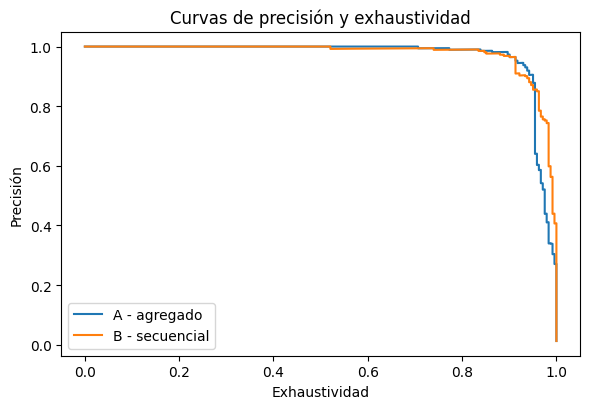

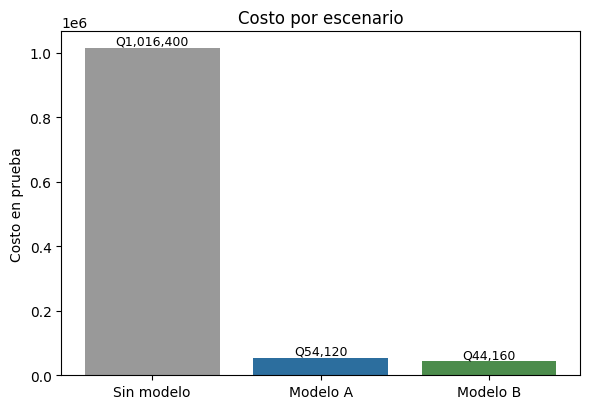

In [10]:
Xtest = frame.loc[frame.split == "test", AGG_COLS].values
ytest = frame.loc[frame.split == "test", "fraud"].values
Xtest_s = scaler_A.transform(Xtest)
test_raw = make_tensors(t_val_end, None)
Xtest_cont, Xtest_cat, Xtest_chan = build_X(test_raw)

scoreA_test = modelo_A.predict_proba(Xtest_s)[:, 1]
with torch.no_grad():
    scoreB_test = torch.sigmoid(
        modelo_B(Xtest_cont, Xtest_cat, Xtest_chan)
    ).numpy()
scoreC_test = modelo_C.predict_proba(
    np.stack([scoreA_test, scoreB_test], axis=1)
)[:, 1]

auc_pr_A_test = average_precision_score(ytest, scoreA_test)
auc_pr_B_test = average_precision_score(ytest, scoreB_test)
auc_pr_C_test = average_precision_score(ytest, scoreC_test)


def threshold_metrics(model_name, labels, score, threshold):
    prediction = (score >= threshold).astype(int)
    false_negatives = int(((prediction == 0) & (labels == 1)).sum())
    false_positives = int(((prediction == 1) & (labels == 0)).sum())
    return {
        "modelo": model_name,
        "umbral": threshold,
        "precision": precision_score(labels, prediction, zero_division=0),
        "exhaustividad": recall_score(labels, prediction, zero_division=0),
        "F1": f1_score(labels, prediction, zero_division=0),
        "FN": false_negatives,
        "FP": false_positives,
        "costo": false_negatives * COST_FN + false_positives * COST_FP,
    }


metrics_A = threshold_metrics("A - agregado", ytest, scoreA_test, threshold_A)
metrics_B = threshold_metrics("B - secuencial", ytest, scoreB_test, threshold_B)
test_comparison = pd.DataFrame(
    [
        {"modelo": "A - agregado", "AUC_PR": auc_pr_A_test, **metrics_A},
        {"modelo": "B - secuencial", "AUC_PR": auc_pr_B_test, **metrics_B},
    ]
)
display(test_comparison)
print(f"AUC-PR de C en prueba: {auc_pr_C_test:.4f}")

plt.figure(figsize=(6, 4.2))
for model_name, score in [
    ("A - agregado", scoreA_test),
    ("B - secuencial", scoreB_test),
]:
    precision_values, recall_values, _ = precision_recall_curve(ytest, score)
    plt.plot(recall_values, precision_values, label=model_name)
plt.xlabel("Exhaustividad")
plt.ylabel("Precisión")
plt.title("Curvas de precisión y exhaustividad")
plt.legend()
plt.tight_layout()
plt.savefig("figs/fig1_pr_curves_AB.png", dpi=180)
plt.show()

no_model_cost = int(ytest.sum()) * COST_FN
cost_labels = ["Sin modelo", "Modelo A", "Modelo B"]
test_costs = [no_model_cost, metrics_A["costo"], metrics_B["costo"]]
plt.figure(figsize=(6, 4.2))
bars = plt.bar(cost_labels, test_costs, color=["#999999", "#2c6e9e", "#4c8c4c"])
for bar, cost in zip(bars, test_costs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        cost,
        f"Q{cost:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.ylabel("Costo en prueba")
plt.title("Costo por escenario")
plt.tight_layout()
plt.savefig("figs/fig4_costo_escenarios.png", dpi=180)
plt.show()

## 10. Pruebas de falsificación

La primera prueba destruye el orden de las siete transacciones históricas. La transacción actual permanece al final, por lo que la identidad del evento evaluado no cambia.

La segunda prueba separa el desempeño de A y B por mecanismo de fraude. Esta comparación permite verificar si cualquier ventaja de B es general o si se concentra en un patrón específico.

AUC-PR con historia ordenada: 0.9768
AUC-PR con historia permutada: 0.9468
Diferencia absoluta: +0.0301


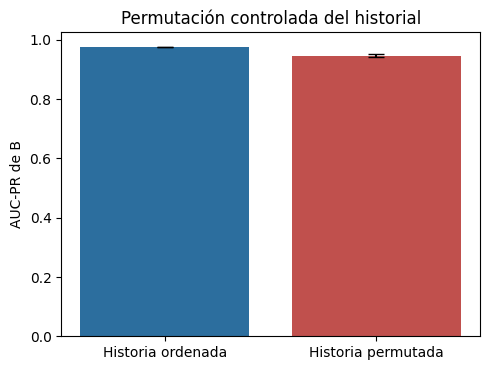

,fraud_type,n_pos,AUC_PR_A,AUC_PR_B,ventaja_B
0,escalada,23,0.967311,0.717283,-0.250028
1,rafaga,207,0.961905,0.977034,0.015129
2,canal_raro,12,0.988095,0.475707,-0.512389


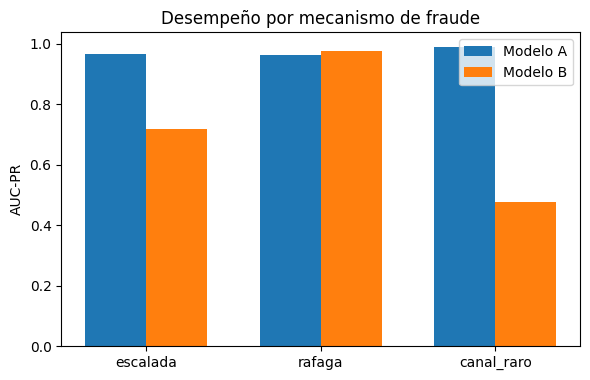

In [11]:
permuted_auc_scores = []
for repetition in range(10):
    perm_cont, perm_cat, perm_chan = build_X(
        test_raw,
        shuffle_history=True,
        rng=np.random.default_rng(1000 + repetition),
    )
    with torch.no_grad():
        permuted_score = torch.sigmoid(
            modelo_B(perm_cont, perm_cat, perm_chan)
        ).numpy()
    permuted_auc_scores.append(average_precision_score(ytest, permuted_score))

permuted_auc_scores = np.array(permuted_auc_scores)
permutation_drop = auc_pr_B_test - permuted_auc_scores.mean()
print(f"AUC-PR con historia ordenada: {auc_pr_B_test:.4f}")
print(f"AUC-PR con historia permutada: {permuted_auc_scores.mean():.4f}")
print(f"Diferencia absoluta: {permutation_drop:+.4f}")

plt.figure(figsize=(5, 3.8))
plt.bar(
    ["Historia ordenada", "Historia permutada"],
    [auc_pr_B_test, permuted_auc_scores.mean()],
    yerr=[0, permuted_auc_scores.std()],
    color=["#2c6e9e", "#c0504d"],
    capsize=6,
)
plt.ylabel("AUC-PR de B")
plt.title("Permutación controlada del historial")
plt.tight_layout()
plt.savefig("figs/fig2_permutacion.png", dpi=180)
plt.show()

evaluation = pd.DataFrame(
    {
        "y": ytest,
        "fraud_type": test_raw["ftype"],
        "score_A": scoreA_test,
        "score_B": scoreB_test,
    }
)
mechanism_rows = []
for fraud_type in ["escalada", "rafaga", "canal_raro"]:
    positive_mask = evaluation["fraud_type"] == fraud_type
    comparison_mask = positive_mask | (evaluation["y"] == 0)
    subset = evaluation[comparison_mask]
    auc_a = average_precision_score(subset["y"], subset["score_A"])
    auc_b = average_precision_score(subset["y"], subset["score_B"])
    mechanism_rows.append(
        {
            "fraud_type": fraud_type,
            "n_pos": int(positive_mask.sum()),
            "AUC_PR_A": auc_a,
            "AUC_PR_B": auc_b,
            "ventaja_B": auc_b - auc_a,
        }
    )

mechanism_table = pd.DataFrame(mechanism_rows)
display(mechanism_table)
mechanism_table.to_csv("artefactos/tabla_mecanismo.csv", index=False)

positions = np.arange(len(mechanism_table))
width = 0.35
plt.figure(figsize=(6, 3.9))
plt.bar(positions - width / 2, mechanism_table["AUC_PR_A"], width=width, label="Modelo A")
plt.bar(positions + width / 2, mechanism_table["AUC_PR_B"], width=width, label="Modelo B")
plt.xticks(positions, mechanism_table["fraud_type"])
plt.ylabel("AUC-PR")
plt.title("Desempeño por mecanismo de fraude")
plt.legend()
plt.tight_layout()
plt.savefig("figs/fig3_mecanismo.png", dpi=180)
plt.show()

In [12]:
test_days = (
    frame.loc[frame.split == "test", "timestamp"].max()
    - frame.loc[frame.split == "test", "timestamp"].min()
).total_seconds() / 86400
monthly_factor = 30.0 / test_days
monthly_savings_B_vs_A = (metrics_A["costo"] - metrics_B["costo"]) * monthly_factor

results = {
    "seed": SEED,
    "transactions": int(len(df)),
    "samples": int(len(frame)),
    "fraud_rate": float(df["fraud"].mean()),
    "split_counts": {key: int(value) for key, value in frame["split"].value_counts().items()},
    "auc_pr": {
        "A_validation": float(auc_pr_A_val),
        "B_validation": float(auc_pr_B_val),
        "A_test": float(auc_pr_A_test),
        "B_test": float(auc_pr_B_test),
        "C_test": float(auc_pr_C_test),
    },
    "bet": {
        "hybrid_mean": float(hybrid_fold_scores.mean()),
        "control_mean": float(control_fold_scores.mean()),
        "margin_mean": float(mean_margin),
        "success": bet_success,
    },
    "threshold_metrics": {
        "A": {key: float(value) if isinstance(value, np.floating) else value for key, value in metrics_A.items()},
        "B": {key: float(value) if isinstance(value, np.floating) else value for key, value in metrics_B.items()},
    },
    "permutation": {
        "ordered_auc": float(auc_pr_B_test),
        "permuted_mean_auc": float(permuted_auc_scores.mean()),
        "permuted_std_auc": float(permuted_auc_scores.std()),
        "absolute_drop": float(permutation_drop),
    },
    "mechanisms": mechanism_rows,
    "economics": {
        "no_model_test_cost": float(no_model_cost),
        "B_vs_A_test_savings": float(metrics_A["costo"] - metrics_B["costo"]),
        "test_days": float(test_days),
        "B_vs_A_monthly_savings_at_simulated_scale": float(monthly_savings_B_vs_A),
    },
}

with open("artefactos/resultados.json", "w", encoding="utf-8") as results_file:
    json.dump(results, results_file, ensure_ascii=False, indent=2)

print(json.dumps(results, ensure_ascii=False, indent=2))

{
  "seed": 20260905,
  "transactions": 102087,
  "samples": 97187,
  "fraud_rate": 0.011441221703057195,
  "split_counts": {
    "train": 58313,
    "val": 19437,
    "test": 19437
  },
  "auc_pr": {
    "A_validation": 0.9477166792471163,
    "B_validation": 0.957106070460863,
    "A_test": 0.9696177048183634,
    "B_test": 0.9768082247366168,
    "C_test": 0.9846654019172589
  },
  "bet": {
    "hybrid_mean": 0.9747517249409976,
    "control_mean": 0.9611674480150935,
    "margin_mean": 0.01358427692590416,
    "success": true
  },
  "threshold_metrics": {
    "A": {
      "modelo": "A - agregado",
      "umbral": 0.04,
      "precision": 0.84,
      "exhaustividad": 0.9545454545454546,
      "F1": 0.8936170212765957,
      "FN": 11,
      "FP": 44,
      "costo": 54120.0
    },
    "B": {
      "modelo": "B - secuencial",
      "umbral": 0.6,
      "precision": 0.6102564102564103,
      "exhaustividad": 0.9834710743801653,
      "F1": 0.7531645569620253,
      "FN": 4,
      "FP": 

## 11. Matriz de evidencias y recomendación

| Evidencia | Figura o tabla | Conclusión | Limitación |
|---|---|---|---|
| Integridad de datos | Secciones 1 y 2 | Se generaron 102,087 transacciones con una tasa de fraude de 1.14 por ciento y una partición temporal estricta | Los datos son sintéticos |
| Comparación común | Tabla de la sección 9 y figura 1 | B alcanza 0.9768 de AUC-PR y A alcanza 0.9696 | La ventaja global de B es pequeña |
| Permutación controlada | Figura 2 | El AUC-PR de B baja de 0.9768 a 0.9468 al alterar solo el historial | La caída absoluta de 0.0301 indica un aporte moderado del orden |
| Prueba por mecanismo | Figura 3 | B mejora en `rafaga` y queda por debajo de A en `escalada` y `canal_raro` | Hay solamente 23 casos de `escalada` y 12 de `canal_raro` en prueba |
| Apuesta C | Sección 6 | El margen medio de 0.0136 supera la regla previa de 0.01 | La estimación varía entre las cinco particiones |
| Decisión económica | Tabla de la sección 9 y figura 4 | B reduce el costo de Q54,120 a Q44,160 | Los costos y la tasa de fraude son simulados |

El Modelo B mejora la exhaustividad y reduce el costo frente a A. A mantiene mayor precisión y F1. Por ello se recomienda complementar el sistema actual con B mediante un piloto en paralelo y no reemplazar A de inmediato.

La evidencia sobre el orden es moderada. La permutación corregida mantiene fija la transacción evaluada y produce una caída absoluta de 0.0301. La ventaja de B se concentra en `rafaga`. B queda por debajo de A en `escalada` y `canal_raro`, por lo que no se concluye que el orden ayude en todos los mecanismos.

La apuesta C cumple la regla previa en validación y alcanza 0.9847 de AUC-PR en prueba. Se conserva como una extensión para el Proyecto Final. Antes de producción se requiere validación con transacciones reales, medición de costos operativos, calibración de puntajes y seguimiento de deriva.